# Machine learning

---

## ATom data

- This notebook makes use of measurements from deployment 1 of NASA's Atmospheric Tomography Mission (ATom), which was carried out in June-August 2016 and consisted of regular 0.2–12 km profiling. (https://doi.org/10.5194/essd-15-3299-2023)
- In this notebook we will look at a dataset containing mixing ratios of hydrogen oxides measured by the Airborne Tropospheric Hydrogen Oxides Sensor (ATHOS) from this deployment, and use it to build up an atmospheric 0-dimensional, 1-box model of OH concentrations. (https://doi.org/10.3334/ORNLDAAC/1877)
- https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

---

## Inspect dataset

In [1]:
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [2]:
df.shape

(6550, 144)

Filtering out the dataset to only keep the columns of interest:

In [3]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'CO_M', 'CH4_M', 'PAN_M', 'HO2_ATHOS']]
# df

In [4]:
from datetime import datetime, timezone
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']
# df['date']

In [5]:
## Unit conversions
from datetime import datetime, timezone
import numpy as np
from pytz import timezone

kb = 1.38e-23 # J K^−1 Boltzmann's constant

for i in range(len(df)):
    # Convert the dates to a timestamp value so that the difference between times can be calculated as an integer
    df.loc[i, "t"] = df["UTC_Start_dt"][i].replace().timestamp() - df["UTC_Start_dt"][0].replace().timestamp()
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 ## molecules cm^3 pressure was in hPa

# df.head()


In [6]:
df['kH2O'] = 1.63e-10 * np.exp(--60/df["Temp"]) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(--110/df["Temp"]) ## ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf


df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] *  df["M"]
df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt


In [7]:
for i in range(len(df)):
    df.loc[i, "O1D"] = (df["jO3_O2_O1D_CAFS"][i] * df["O3_M"][i]) / ((df['kH2O'][i] * df["H2O_M"][i]) + (df['kM'][i]))
    df.loc[i, "source"] = 2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i]
print(df["O1D"].mean())
print(df["source"].mean())
# df.head()

# source should be 10e5

0.05354202636146678
714621.1551027566


In [8]:
df["source"].mean()

np.float64(714621.1551027566)

In [9]:
df["P_atm"] = 0.000987 * df["Pres"]
# df['kCO'] = 1.85e-13 * np.exp(-(65/df['Temp'])) * 24/15 ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCO']  = 1.5e-13  * (1.0 + 0.6 * df["P_atm"]) #where P is the pressure in atmospheres
df['kCH4'] = 2.45e-12 * np.exp(-1775/df['Temp']) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]

for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"])/ ((df['kCO'][i] * df["CO"][i]) + (df['kCH4'][i] * df["CH4"][i]))
df["[OH]_calc"]

0       2.612957e+05
1       1.811806e+05
2       9.325155e+04
3       1.084854e+05
4       1.370618e+05
            ...     
6545    5.493687e+06
6546    5.625367e+06
6547    5.694019e+06
6548    5.569411e+06
6549    6.971896e+06
Name: [OH]_calc, Length: 6550, dtype: float64

In [10]:
from sklearn.metrics import r2_score

## Machine learning

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler = StandardScaler()
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

# Example data
X = df_inputs   # 100 samples, 5 input features
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]  # single output

X_train = df_inputs[df["date"] < "2016-08-23"]
X_train_normalised = scaler.fit_transform(X_train)

X_train_HO2 = df_inputs_HO2[df["date"] < "2016-08-23"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

y_train = df[["[OH]_measured"]][df["date"] < "2016-08-23"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
X_test_normalised = scaler.fit_transform(X_test)

X_test_HO2 = df_inputs_HO2[(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
# y_test_normalised = scaler.transform(y_test)



In [12]:
print(X_train.shape)
print(X_test.shape)

(6136, 7)
(414, 7)


### Linear regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

Model score on training data: 0.47823332401838137
Model score on testing data: 0.040717526992043895
WITH HO2
Model score on training data: 0.5626179047562513
Model score on testing data: 0.28327356745149135


Text(0.5, 1.0, 'Linear regression')

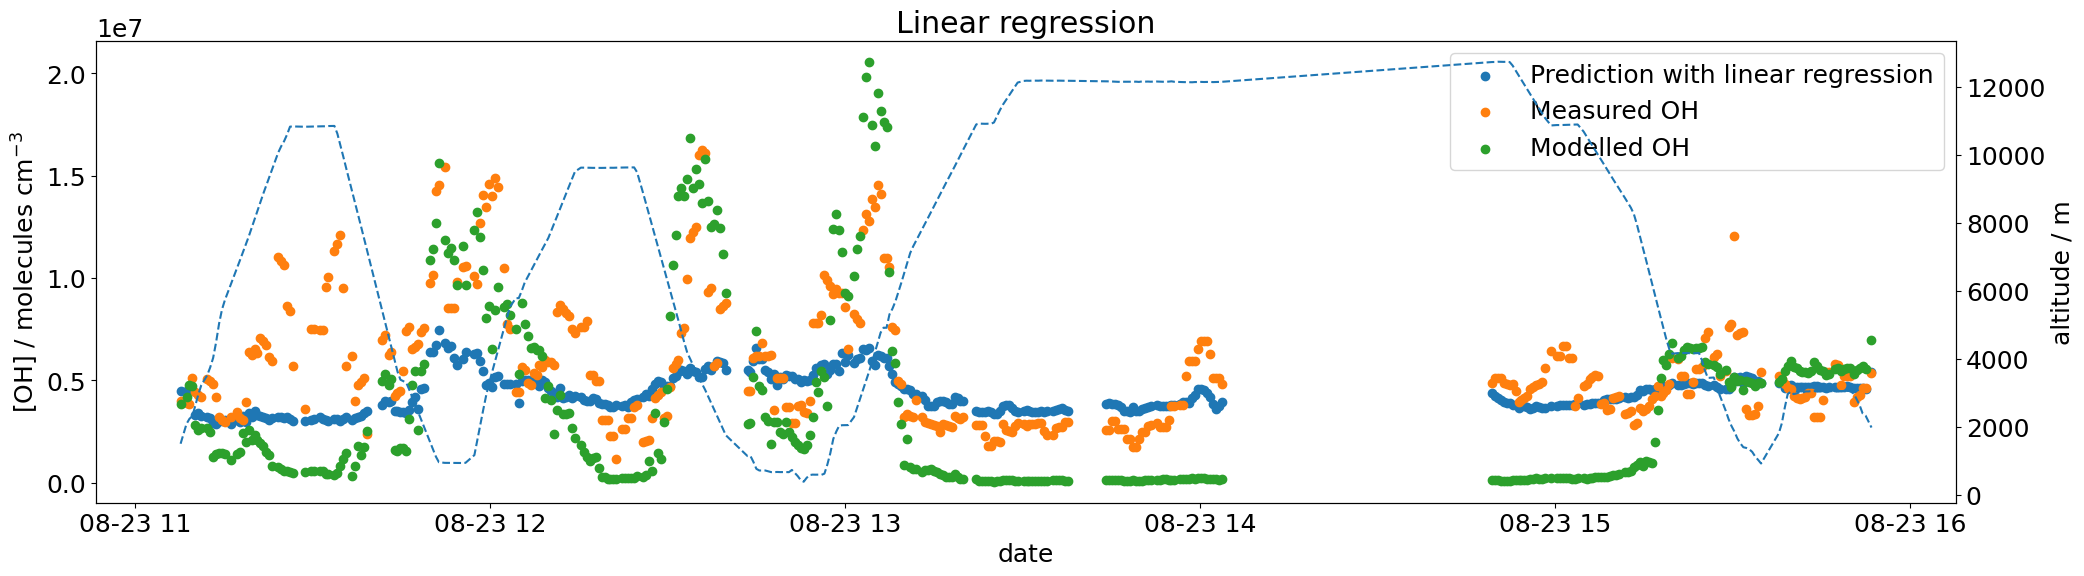

In [13]:


# X = df_inputs
# y = df["[OH]_measured"]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.4, random_state=42
# )
import matplotlib as mpl
import matplotlib.pyplot as plt
reg = LinearRegression().fit(X_train, y_train)
pred_reg = reg.predict(X_test)

reg_HO2 = LinearRegression().fit(X_train_HO2, y_train)
pred_reg_HO2 = reg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {reg.score(X_train, y_train)}")
print(f"Model score on testing data: {reg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {reg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {reg_HO2.score(X_test_HO2, y_test)}")


mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], pred_reg, label = "Prediction with linear regression")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], df["Altitude"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Linear regression")



[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


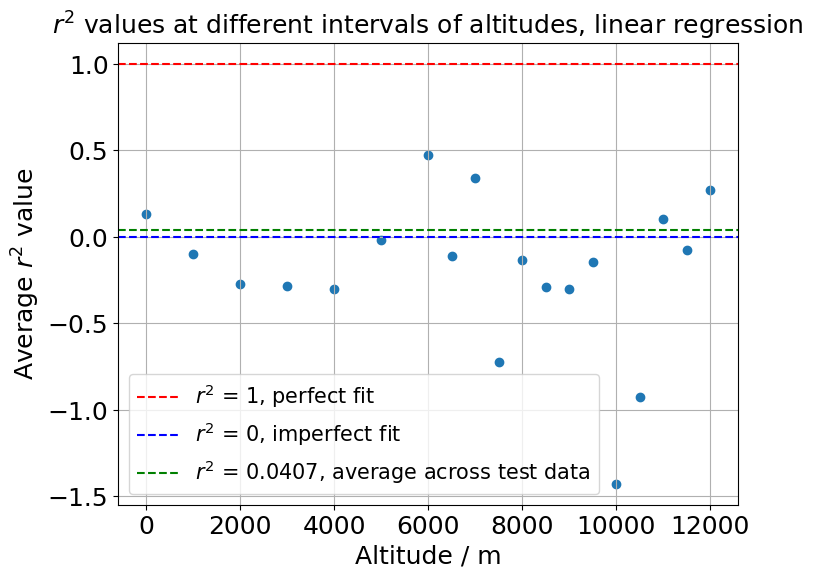

In [14]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(reg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (reg.score(X_test, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(reg.score(X_test, y_test), 4)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, linear regression")
plt.legend(prop={'size':15})

plt.grid()

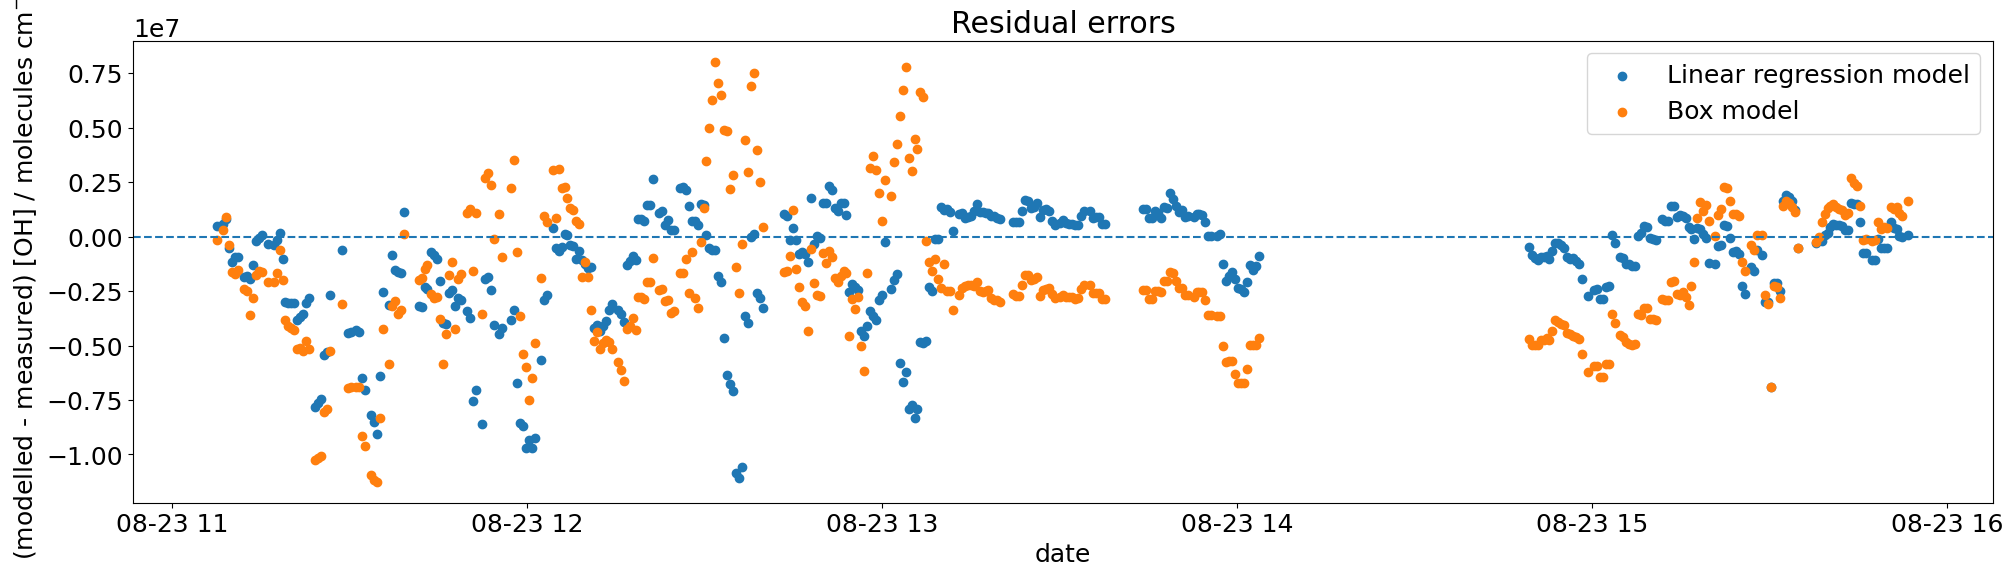

RMSE: 2934714.912950316
RMSE with HO2: 2536701.553350576


In [15]:
mpl.rcParams["font.size"] = 18

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (reg.predict(X_test) - y_test), label='Linear regression model')

y_test = df["[OH]_measured"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]

plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_reg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_reg_HO2)))

### Random forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

In [16]:
# param_grid_rf = {
#     'n_estimators': range(1, 5, 1),
#     'max_depth': range(1, 5, 1),
#     'max_features': range(1, 5, 1)
# }

# grid_rf = GridSearchCV(rf, param_grid = param_grid_rf, cv = kf, scoring = 'f1_weighted').fit(X, y)

# print(grid_rf.best_params_)
# print(grid_rf.best_score_)

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model score on training data: 0.9806158401965822
Model score on testing data: 0.1327501016520467
WITH HO2
Model score on training data: 0.9778591208229287
Model score on testing data: 0.2590424688227114


Text(0.5, 1.0, 'Random forest')

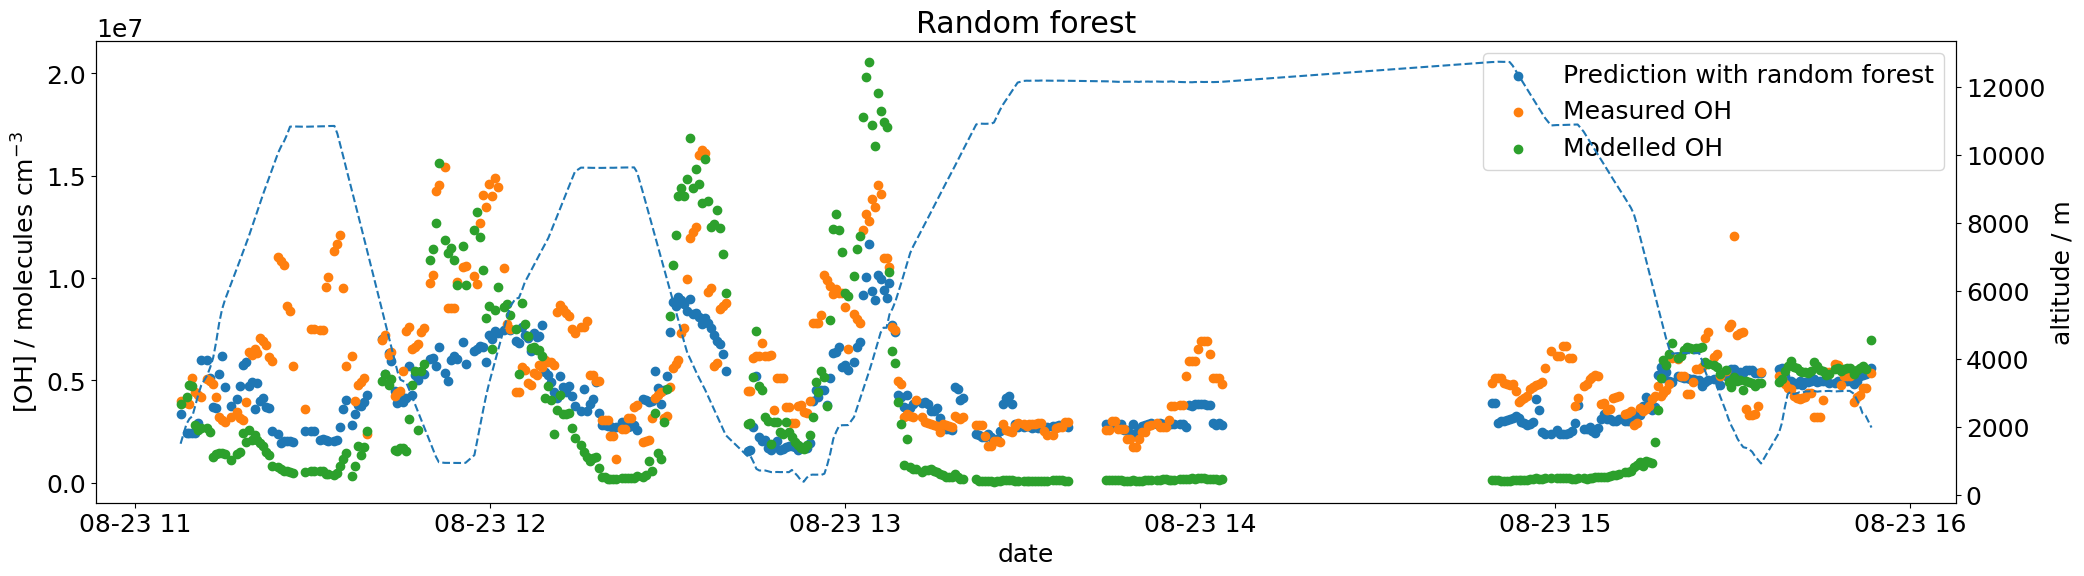

In [17]:
from sklearn.ensemble import RandomForestRegressor
rfreg = RandomForestRegressor()

rfreg.fit(X_train, y_train)

pred_rfreg = rfreg.predict(X_test)


rfreg_HO2 = RandomForestRegressor()

rfreg_HO2.fit(X_train_HO2, y_train)

pred_rfreg_HO2 = rfreg_HO2.predict(X_test_HO2)


print(f"Model score on training data: {rfreg.score(X_train, y_train)}")
print(f"Model score on testing data: {rfreg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {rfreg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {rfreg_HO2.score(X_test_HO2, y_test)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], pred_rfreg, label = "Prediction with random forest")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], df["Altitude"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Random forest")



[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


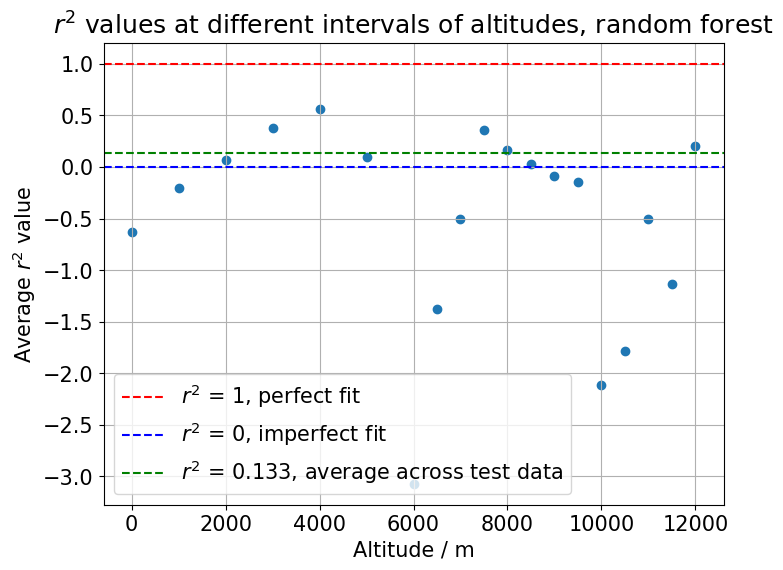

In [36]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(rfreg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (rfreg.score(X_test, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(rfreg.score(X_test, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, random forest")
plt.legend(prop={'size':15})

plt.grid()

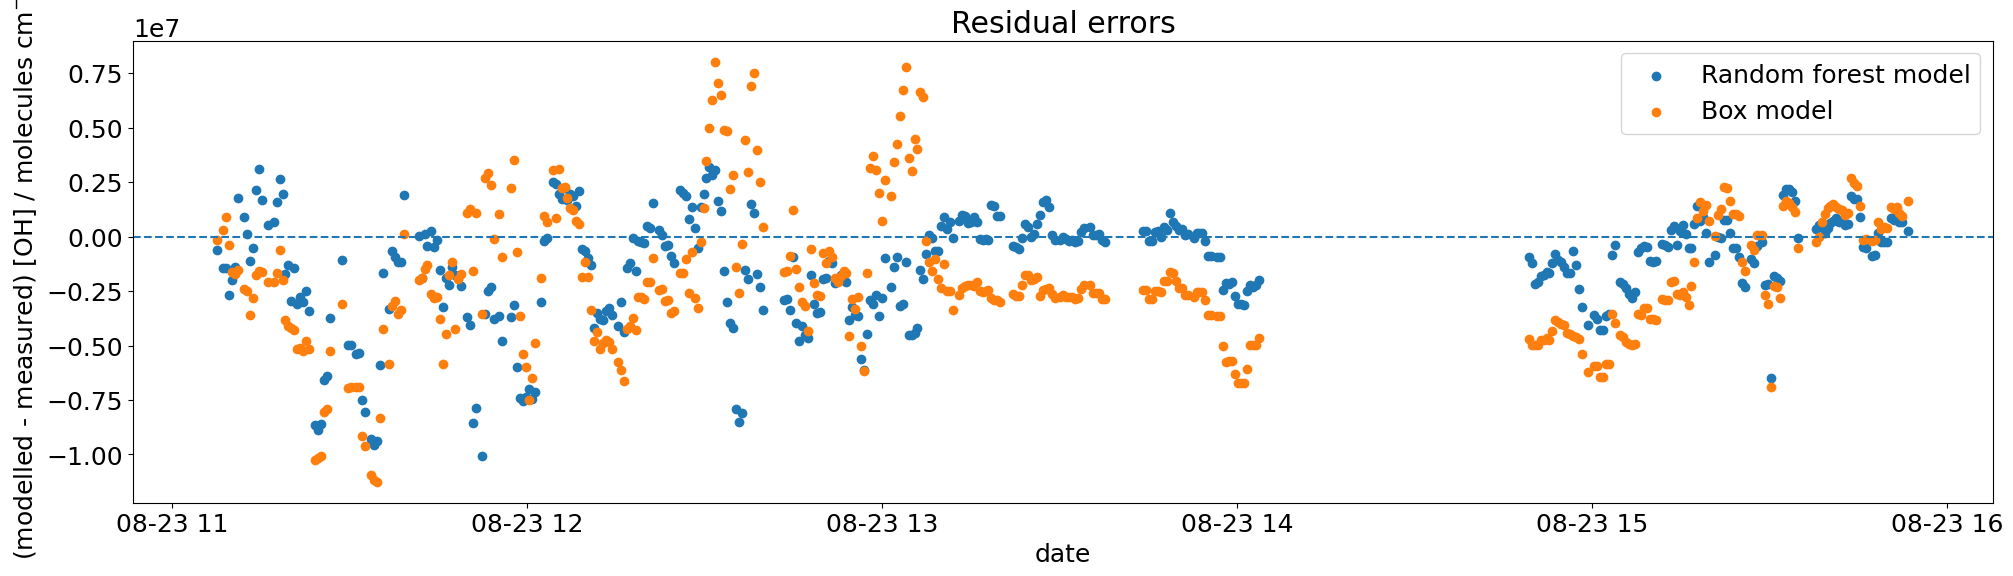

RMSE: 2790389.268269681
RMSE with HO2: 2579225.551049518


In [20]:
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (rfreg.predict(X_test) - y_test),label='Random forest model')
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rfreg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_rfreg_HO2)))

### Feature importance with random forest

Text(0, 0.5, 'Feature')

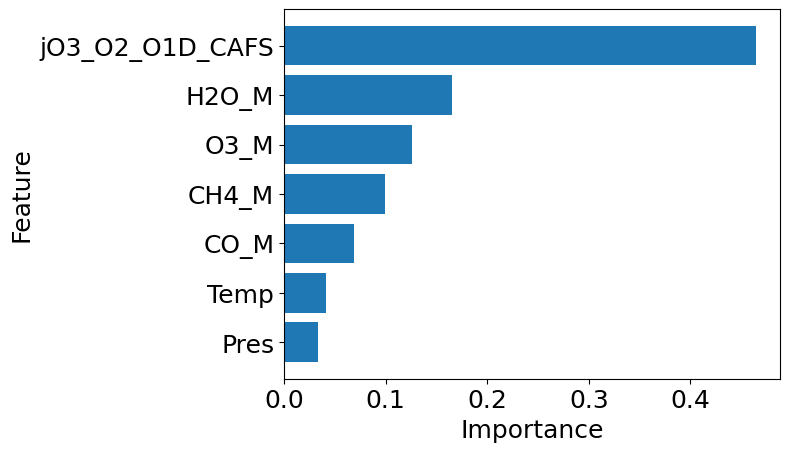

In [21]:
importances = rfreg.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")

Results are as expected - the production of OH depends strongly on the reaction between O(1D) and H2O and this process requires UV from sunlight.

### Ridge regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

Ridge regression is an example of a regularisation procedure, which is an extension of the linear model.

This model solves a regression model where the loss function is the linear least squares function and regularization is given by the l2-norm

Used when there is collinearity in input values and ordinary least squares would overfit training data.

Model score on training data: 0.4782330198187885
Model score on testing data: -0.8066649396080066
WITH HO2
Model score on training data: 0.5626178643926382
Model score on testing data: -0.5943272024472712


Text(0.5, 1.0, 'Ridge regression')

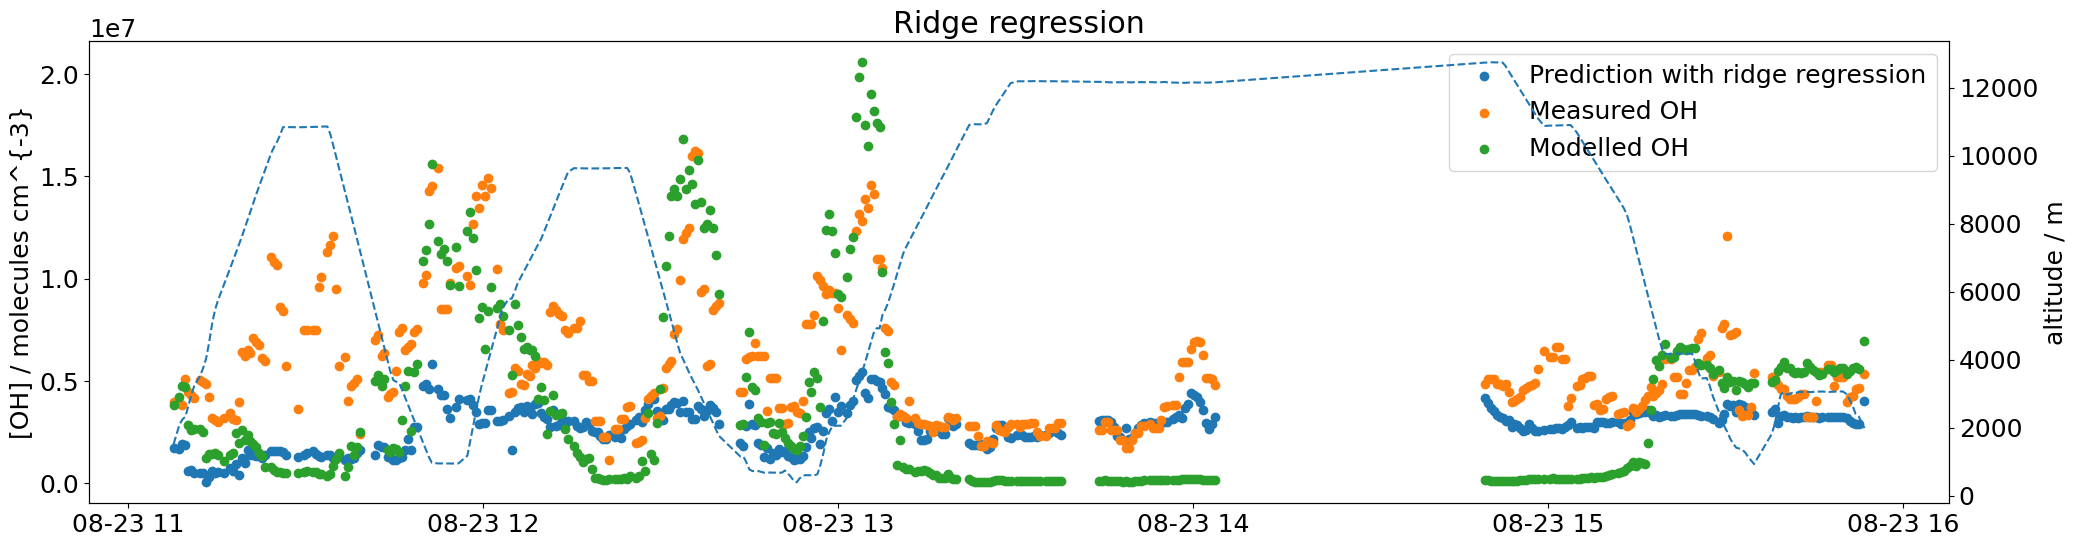

In [22]:
import sklearn
from sklearn.linear_model import Ridge

X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_measured"]  # single output

# X_train = df_inputs[df["date"] > "2016-07-30"]
X_train_normalised = scaler.fit_transform(X_train)
# y_train = df[["[OH]_measured"]][df["date"] > "2016-07-30"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
X_test_normalised = scaler.fit_transform(X_test)
y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
# y_test_normalised = scaler.transform(y_test)

ridgereg = Ridge(alpha=1)  # alpha controls the regularization strength
ridgereg.fit(X_train_normalised, y_train)

pred_ridgereg = ridgereg.predict(X_test_normalised)

ridgereg_HO2 = Ridge(alpha=1)  # alpha controls the regularization strength
ridgereg_HO2.fit(X_train_normalised_HO2, y_train)

pred_ridgereg_HO2 = ridgereg_HO2.predict(X_test_normalised_HO2)


print("Model score on training data:", ridgereg.score(X_train_normalised, y_train))
print("Model score on testing data:", ridgereg.score(X_test_normalised, y_test))

print("WITH HO2")

print("Model score on training data:", ridgereg_HO2.score(X_train_normalised_HO2, y_train))
print("Model score on testing data:", ridgereg_HO2.score(X_test_normalised_HO2, y_test))

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_ylabel('[OH] / molecules cm^{-3}')
ax1.scatter(df["date"][X_test.index], pred_ridgereg, label = "Prediction with ridge regression")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], df["Altitude"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

plt.title("Ridge regression")

[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


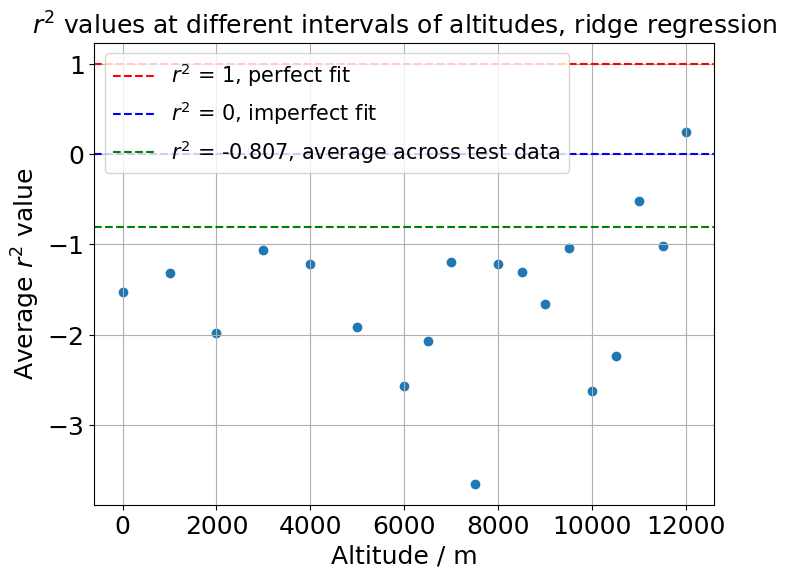

In [23]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(ridgereg.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (ridgereg.score(X_test_normalised, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(ridgereg.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, ridge regression")
plt.legend(prop={'size':15})

plt.grid()

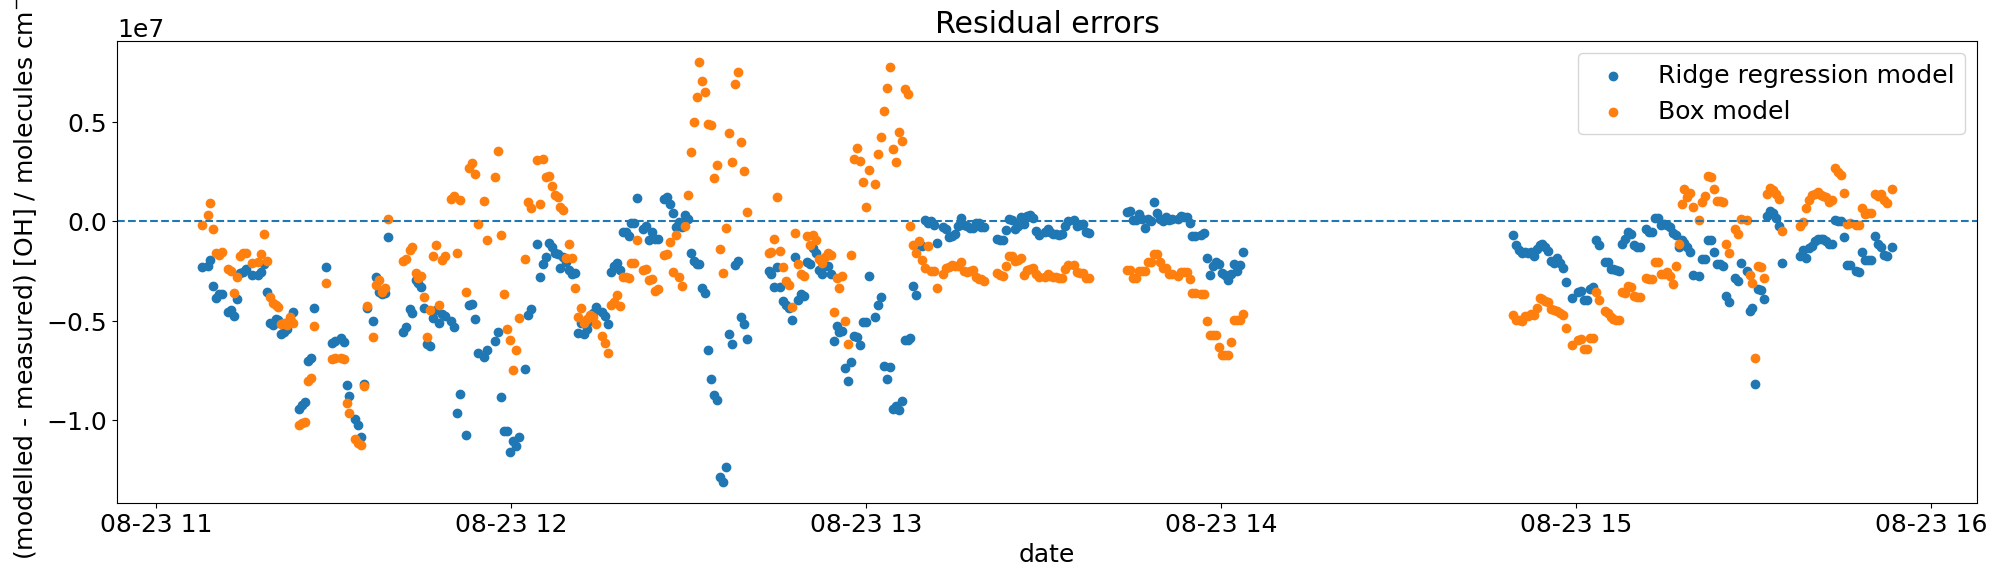

RMSE: 4027462.195261471
RMSE with HO2: 3783392.4445604235


In [24]:
mpl.rcParams["font.size"] = 18

y_test = df["[OH]_measured"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (ridgereg.predict(X_test_normalised) - y_test),label='Ridge regression model')
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")


# method call for showing the plot
plt.show()
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridgereg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_ridgereg_HO2)))

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

In [25]:
df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Model score on training data: 0.8067714009540176
Model score on testing data: -0.7002952238530222
WITH HO2 AS TRAINING DATA
Model score on training data: 0.8225549654086218
Model score on testing data: -0.3691823706839654


Text(0.5, 1.0, 'Gradient boosting')

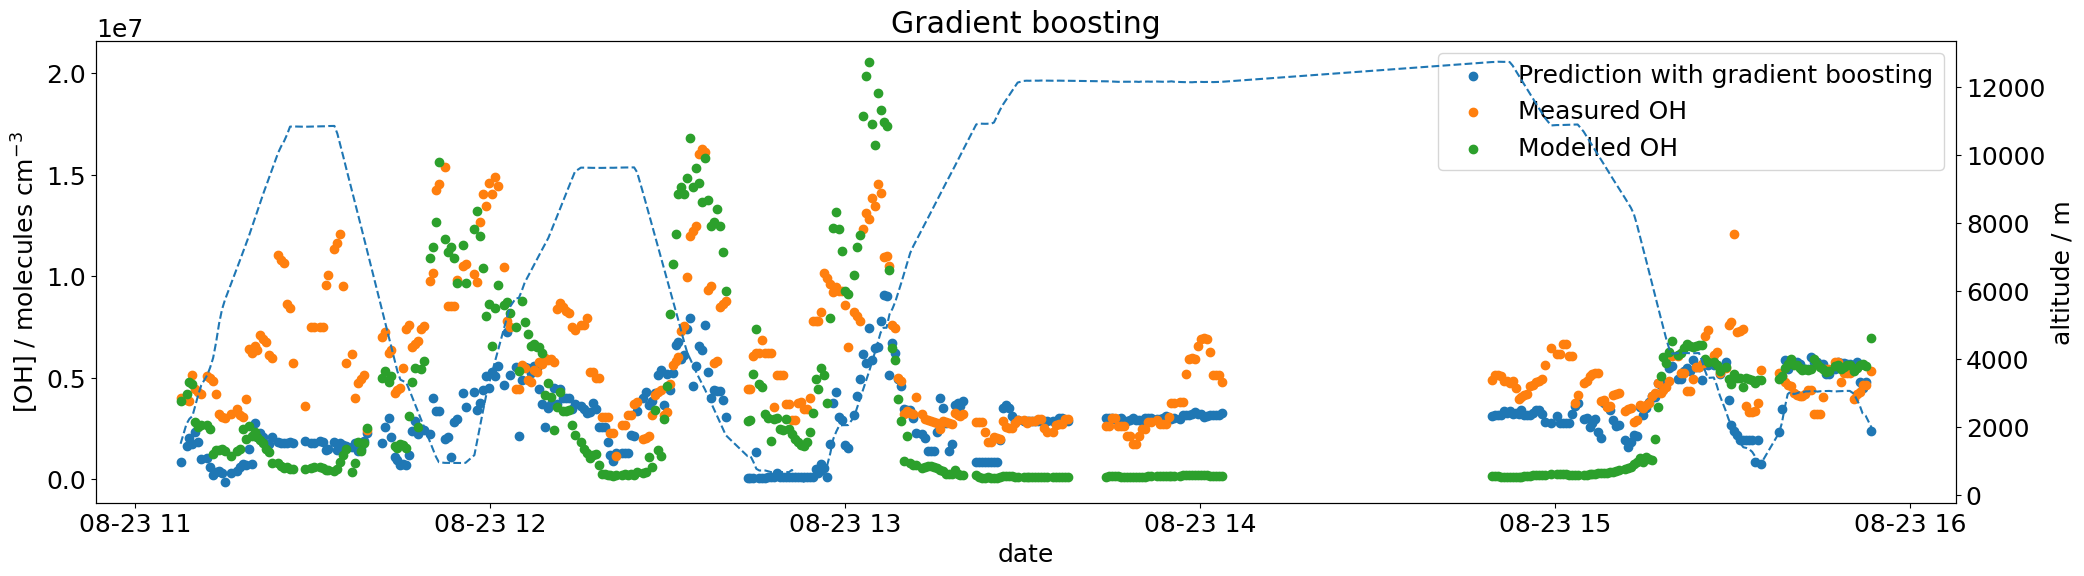

In [26]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Example data
X = df_inputs   # 100 samples, 5 input features
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]  # single output

X_train = df_inputs[df["date"] < "2016-08-23"]
X_train_normalised = scaler.fit_transform(X_train)

X_train_HO2 = df_inputs_HO2[df["date"] < "2016-08-23"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

y_train = df[["[OH]_measured"]][df["date"] < "2016-08-23"]
y_train_normalised = scaler.fit_transform(y_train)

X_test = df_inputs[(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
X_test_normalised = scaler.fit_transform(X_test)

X_test_HO2 = df_inputs_HO2[(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

y_test = df[["[OH]_measured"]][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]
# y_test_normalised = scaler.transform(y_test)

# Normalise

# GBRT model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

model_HO2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

# Train
model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

# Predict
# y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)



print(f"Model score on training data: {model.score(X_train_normalised, y_train)}")
print(f"Model score on testing data: {model.score(X_test_normalised, y_test)}")

print("WITH HO2 AS TRAINING DATA")

print(f"Model score on training data: {model_HO2.score(X_train_normalised_HO2, y_train)}")
print(f"Model score on testing data: {model_HO2.score(X_test_normalised_HO2, y_test)}")

import matplotlib as mpl
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], y_pred, label = "Prediction with gradient boosting")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], df["Altitude"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2
plt.title("Gradient boosting")



[0, 1000, 2000, 3000, 4000, 5000, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000, 10500, 11000, 11500, 12000, 12500]


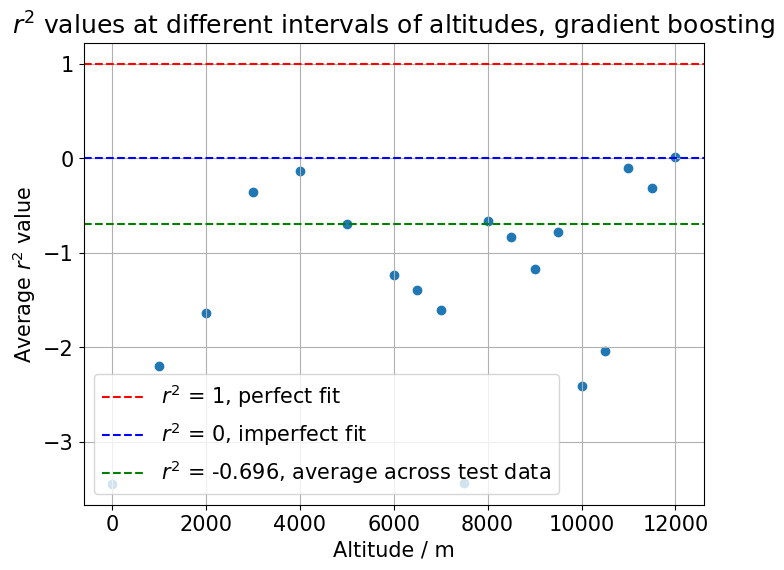

In [35]:
from sklearn.metrics import mean_squared_error
numbers = list(range(0, 6000, 1000))
numbers = numbers + (list(range(6000, 13000, 500)))
metrics_r2 = []
metrics_rmse = []
print(numbers)
for i in range(len(numbers) - 1):
    # print(numbers[i+1])
    X = X_test_normalised[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    y = y_test[(df.iloc[X_test.index]["Altitude"] >= int(numbers[i])) & (df.iloc[X_test.index]["Altitude"] < int(numbers[i + 1]))]
    # print("Model score for altitude:", sklearn.metrics.r2_score(X, y))
    metrics_r2.append(model.score(X, y))
    # metrics_rmse.append(np.sqrt(mean_squared_error(X_test, y_test)))
    # print(i)

fig, ax = plt.subplots(figsize = (8, 6))
plt.rcParams.update({'font.size':15})

plt.scatter(numbers[:-1], metrics_r2)
plt.axhline(y=1, color='r', linestyle='--', label='${r^2}$ = 1, perfect fit')
plt.axhline(y=0, color='b', linestyle='--', label='${r^2}$ = 0, imperfect fit')
plt.axhline(y = (model.score(X_test_normalised, y_test)), color = 'g', linestyle = '--', label = f'$r^2$ = {round(model.score(X_test_normalised, y_test), 3)}, average across test data')
plt.xlabel("Altitude / m")
plt.ylabel("Average $r^2$ value")
plt.title("$r^2$ values at different intervals of altitudes, gradient boosting")
plt.legend(prop={'size':15})

plt.grid()

/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


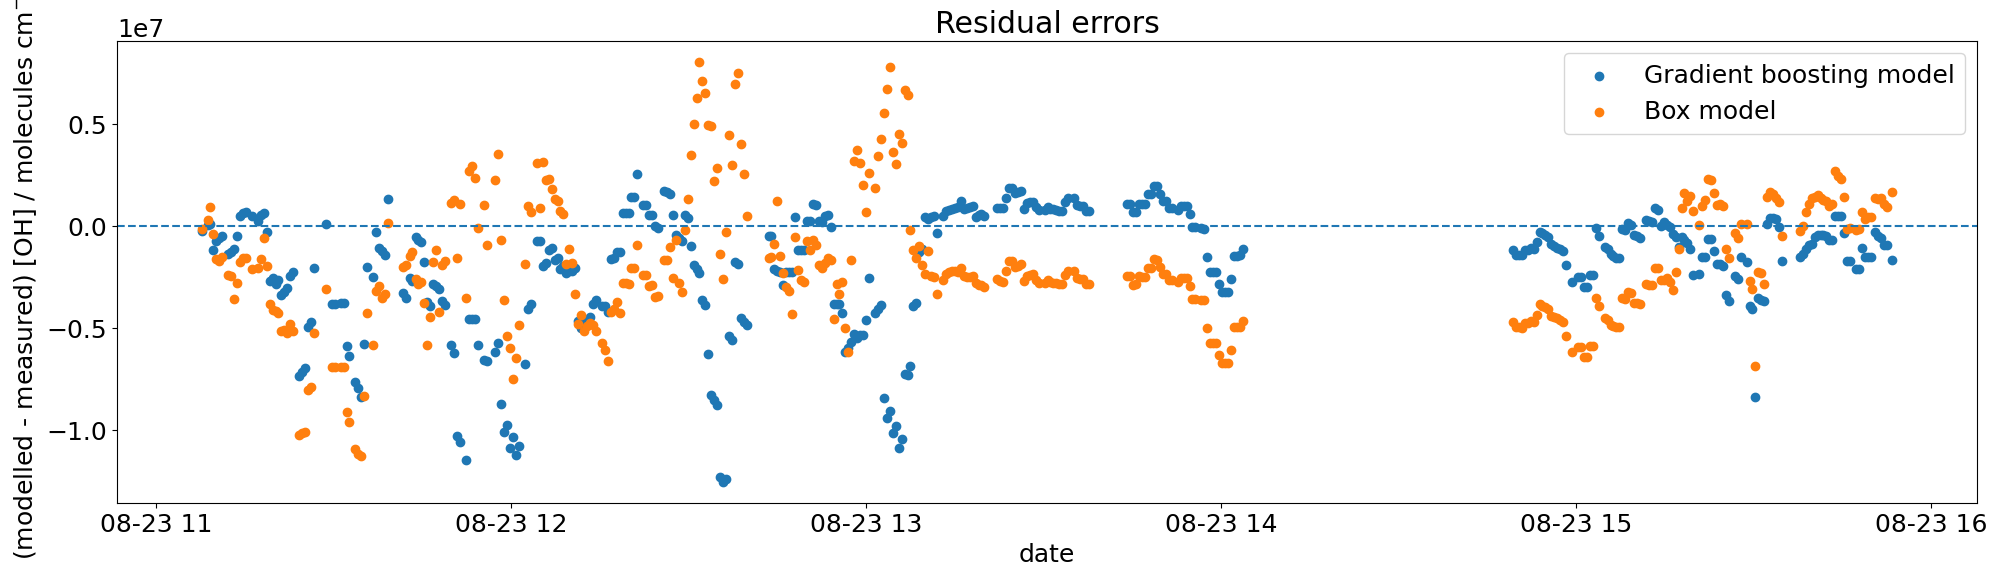

RMSE: 3907102.741443448
RMSE with HO2: 3506092.045735606


In [28]:
mpl.rcParams["font.size"] = 18

y_test = df["[OH]_measured"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (model.predict(X_test) - y_test), label='Gradient boosting model')
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, y_pred_HO2)))

Text(0, 0.5, 'Feature')

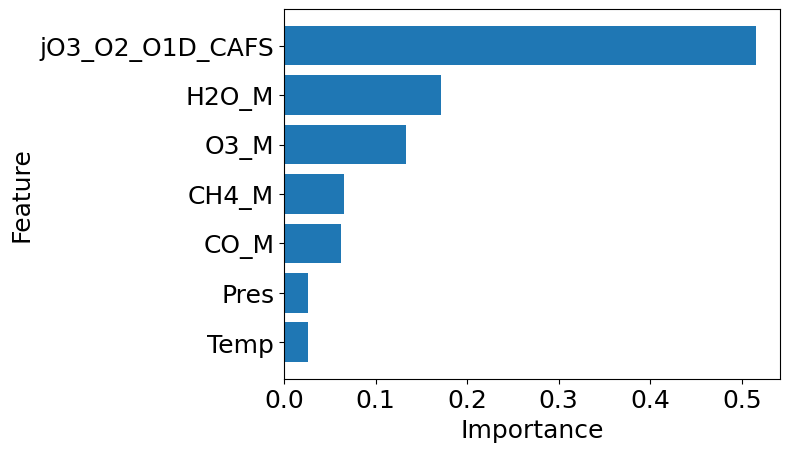

In [29]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

In [30]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


Model score on training data: 0.8067714009540176
Model score on testing data: -0.6957387067038243
WITH HO2 AS TRAINING DATA
Model score on training data: 0.8225549654086218
Model score on testing data: -0.36608262607878417


Text(0.5, 1.0, 'Gradient boosting')

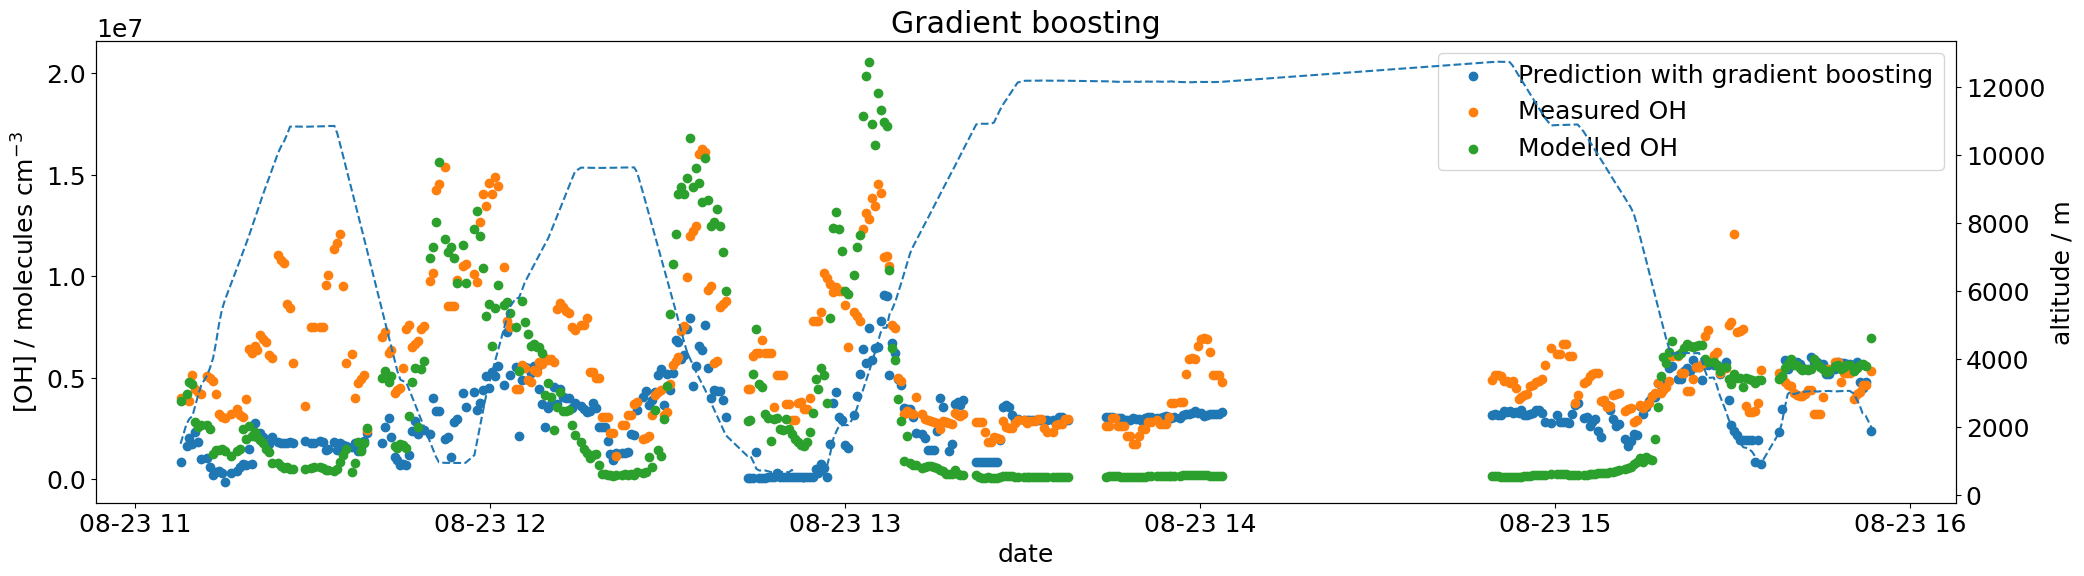

In [31]:

# Normalise

# GBRT model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

model_HO2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

# Train
model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

# Predict
# y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)



print(f"Model score on training data: {model.score(X_train_normalised, y_train)}")
print(f"Model score on testing data: {model.score(X_test_normalised, y_test)}")

print("WITH HO2 AS TRAINING DATA")

print(f"Model score on training data: {model_HO2.score(X_train_normalised_HO2, y_train)}")
print(f"Model score on testing data: {model_HO2.score(X_test_normalised_HO2, y_test)}")

import matplotlib as mpl
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], y_pred, label = "Prediction with gradient boosting")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], df["Altitude"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2
plt.title("Gradient boosting")



/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


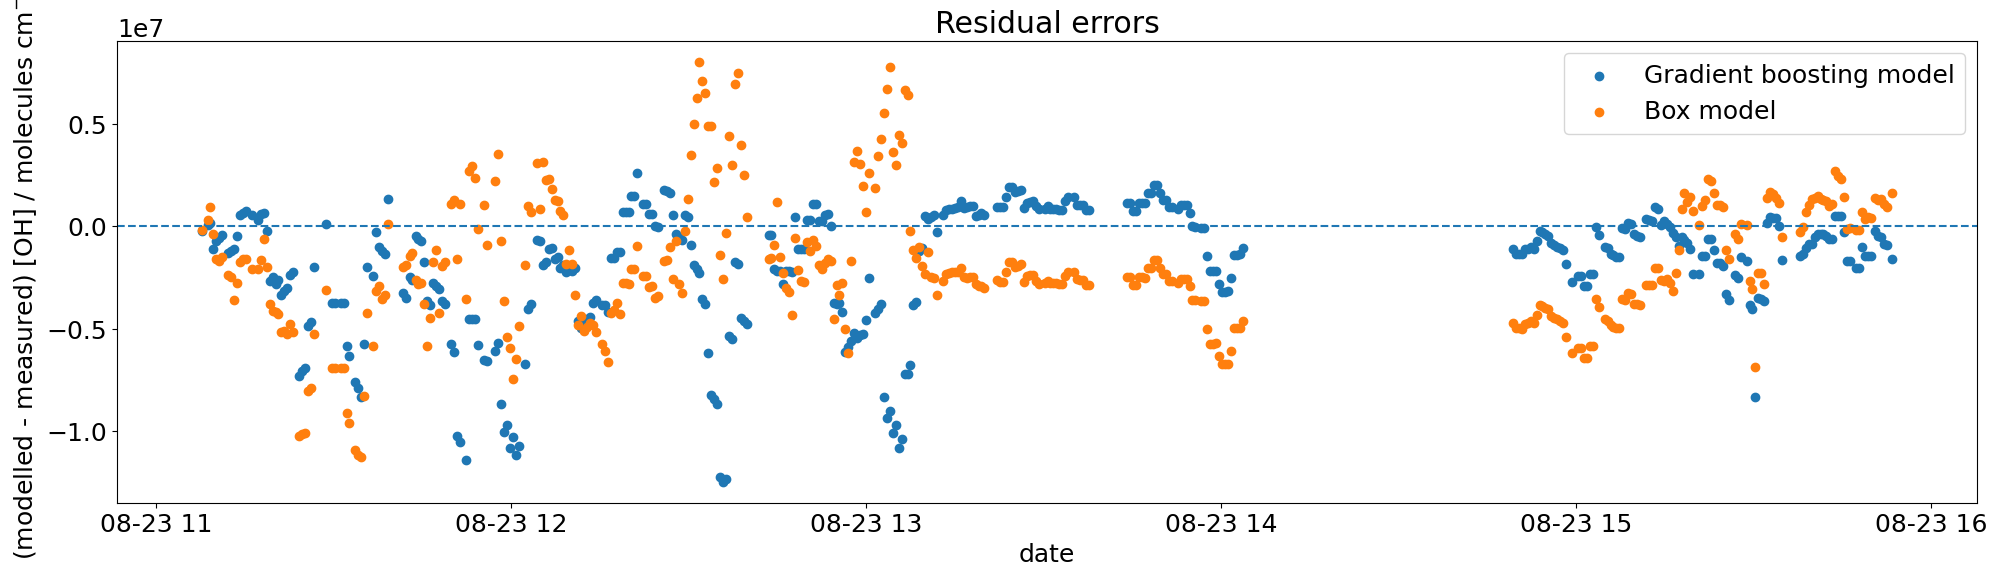

RMSE: 3901864.026557628
RMSE with HO2: 3502121.0086317672


In [32]:
mpl.rcParams["font.size"] = 18

y_test = df["[OH]_measured"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (model.predict(X_test) - y_test), label='Gradient boosting model')
plt.scatter(df["date"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")], (df["[OH]_calc"][(df["date"] > "2016-08-23") & (df["date"] < "2016-08-24")] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, y_pred_HO2)))

Text(0, 0.5, 'Feature')

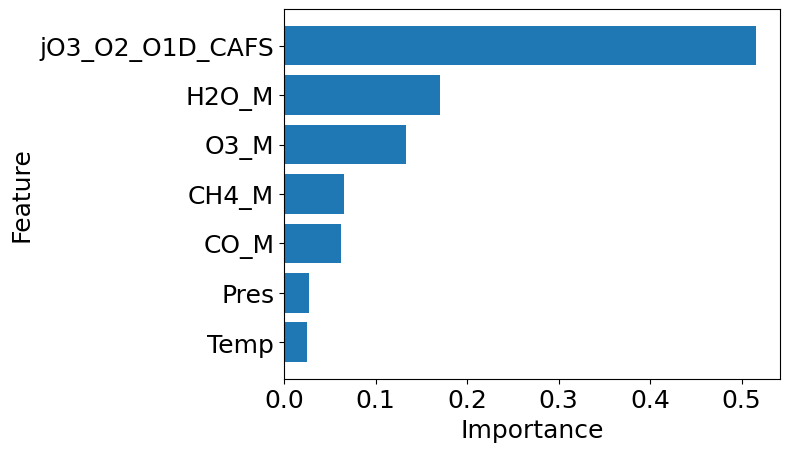

In [33]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")